# Treatment Data Preprocessing for ITE Estimation
**Thesis:** Causal Multimodal Analysis of Breast Cancer Survival (TCGA-BRCA)  
**Stage:** 02_ITE — Step 1: Treatment & Outcome Preprocessing  
**Notebook lives at:** `Thesis_v3/02_ITE/02_treatment_preprocessing/`

## 1. Imports & Path Configuration

In [3]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

# ── Path configuration ────────────────────────────────────────────────────────
# Notebook lives at: Thesis_v3/02_ITE/02_treatment_preprocessing/
NOTEBOOK_DIR = Path(os.path.abspath(''))
BASE_DIR     = NOTEBOOK_DIR.parent.parent          # → Thesis_v3/

CAUSAL_FEATURES_PATH = BASE_DIR / '02_ITE' / '01_preprocessing' / 'output' / 'causal_features_dataset.csv'
FOLLOW_UP_PATH       = BASE_DIR / 'data' / 'drags' / 'follow_up.tsv'
PATHOLOGY_PATH       = BASE_DIR / 'data' / 'drags' / 'pathology_detail.tsv'

OUTPUT_DIR = NOTEBOOK_DIR / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for label, path in [
    ('Causal features',  CAUSAL_FEATURES_PATH),
    ('Follow-up',        FOLLOW_UP_PATH),
    ('Pathology detail', PATHOLOGY_PATH),
]:
    status = '✓ found' if path.exists() else '✗ NOT FOUND'
    print(f'  {label:<20} {status}')
    print(f'    → {path}')
print(f'\n  Output: {OUTPUT_DIR}')


  Causal features      ✓ found
    → C:\Users\olegk\Desktop\Thesis_v3\02_ITE\01_preprocessing\output\causal_features_dataset.csv
  Follow-up            ✓ found
    → C:\Users\olegk\Desktop\Thesis_v3\data\drags\follow_up.tsv
  Pathology detail     ✓ found
    → C:\Users\olegk\Desktop\Thesis_v3\data\drags\pathology_detail.tsv

  Output: C:\Users\olegk\Desktop\Thesis_v3\02_ITE\01_preprocessing\output


## 2. Load Raw Data
**Note:** TCGA GDC exports use `'--` as a sentinel for missing values. These are replaced with `NaN` at load time via `na_values`.

In [5]:
TCGA_NA_VALUES = ["'--", "--", "NA", "N/A", "Not Reported",
                  "not reported", "[Not Available]", "[Unknown]",
                  "[Not Applicable]", "nan", ""]

def load_tcga_tsv(path):
    # Replace TCGA sentinel values with NaN at load time
    df = pd.read_csv(path, sep='\t', low_memory=False,
                     na_values=TCGA_NA_VALUES, keep_default_na=True)
    # Some TCGA files embed a second CDE_ID descriptor row
    if df.shape[0] > 0 and df.iloc[0].astype(str).str.startswith('CDE_ID').any():
        df = df.iloc[1:].reset_index(drop=True)
    return df

def load_causal_csv(path):
    # Replace TCGA sentinels; rename saved pandas index column
    df = pd.read_csv(path, low_memory=False,
                     na_values=TCGA_NA_VALUES, keep_default_na=True)
    if 'Unnamed: 0' in df.columns:
        df.rename(columns={'Unnamed: 0': 'row_index'}, inplace=True)
    return df

causal_df    = load_causal_csv(CAUSAL_FEATURES_PATH)
follow_up_df = load_tcga_tsv(FOLLOW_UP_PATH)
pathology_df = load_tcga_tsv(PATHOLOGY_PATH)

print('Shapes after loading (NaN sentinels replaced):')
print(f'  causal_features_dataset : {causal_df.shape}')
print(f'  follow_up               : {follow_up_df.shape}')
print(f'  pathology_detail        : {pathology_df.shape}')


Shapes after loading (NaN sentinels replaced):
  causal_features_dataset : (1076, 23)
  follow_up               : (9427, 198)
  pathology_detail        : (1096, 86)


## 3. Inspect Causal Features Dataset

In [7]:
print('=== Causal Features Dataset ===')
print(f'  Rows: {causal_df.shape[0]}  |  Columns: {causal_df.shape[1]}')
print('\n--- All column names ---')
for c in causal_df.columns:
    print(f'  {c}')
print('\n--- First 3 rows ---')
causal_df.head(3)


=== Causal Features Dataset ===
  Rows: 1076  |  Columns: 23

--- All column names ---
  row_index
  CLIN_treatment_or_therapy.treatments.diagnoses_['not reported', 'not reported']
  CLIN_ajcc_pathologic_stage.diagnoses_Stage IV
  CLIN_ajcc_pathologic_m.diagnoses_M1
  CLIN_ajcc_pathologic_n.diagnoses_N1b
  CLIN_ajcc_staging_system_edition.diagnoses_5th
  CLIN_ajcc_staging_system_edition.diagnoses_6th
  CLIN_age_at_index.demographic
  CLIN_treatment_or_therapy.treatments.diagnoses_['yes', 'yes']
  CLIN_ajcc_pathologic_n.diagnoses_N0 (i-)
  CLIN_ajcc_pathologic_n.diagnoses_NX
  PROT_4EBP1
  PROT_ZAP-70
  METH_cg00101629
  CLIN_ajcc_pathologic_t.diagnoses_T4b
  RNA_ENSG00000264589.4
  CLIN_tissue_or_organ_of_origin.diagnoses_Lower-inner quadrant of breast
  CLIN_tissue_or_organ_of_origin.diagnoses_Breast, NOS
  METH_cg19851563
  CLIN_ajcc_staging_system_edition.diagnoses_4th
  CLIN_ajcc_pathologic_stage.diagnoses_Stage III
  OS.time
  OS

--- First 3 rows ---


,row_index,"CLIN_treatment_or_therapy.treatments.diagnoses_['not reported', 'not reported']",CLIN_ajcc_pathologic_stage.diagnoses_Stage IV,CLIN_ajcc_pathologic_m.diagnoses_M1,CLIN_ajcc_pathologic_n.diagnoses_N1b,CLIN_ajcc_staging_system_edition.diagnoses_5th,CLIN_ajcc_staging_system_edition.diagnoses_6th,CLIN_age_at_index.demographic,"CLIN_treatment_or_therapy.treatments.diagnoses_['yes', 'yes']",CLIN_ajcc_pathologic_n.diagnoses_N0 (i-),CLIN_ajcc_pathologic_n.diagnoses_NX,PROT_4EBP1,PROT_ZAP-70,METH_cg00101629,CLIN_ajcc_pathologic_t.diagnoses_T4b,RNA_ENSG00000264589.4,CLIN_tissue_or_organ_of_origin.diagnoses_Lower-inner quadrant of breast,"CLIN_tissue_or_organ_of_origin.diagnoses_Breast, NOS",METH_cg19851563,CLIN_ajcc_staging_system_edition.diagnoses_4th,CLIN_ajcc_pathologic_stage.diagnoses_Stage III,OS.time,OS
0,TCGA-BH-A0W3,0,0,0,0,0,0,58.0000,0,0,0,0.0000,0.0000,0.0000,0,0.3966,0,1,0.0000,0,0,728.0000,0
1,TCGA-AR-A24V,0,0,0,0,0,1,52.0000,1,0,0,-0.2578,-0.0939,-2.7500,0,-0.8555,0,1,2.1384,0,0,3203.0000,0
2,TCGA-E9-A1NE,0,0,0,0,0,0,28.0000,1,0,0,-0.1883,2.0821,1.6983,0,-0.2132,0,1,0.8509,0,0,1088.0000,0


## 4. Identify Patient IDs
The causal_df index was saved as `Unnamed: 0` (renamed to `row_index`). We detect whether it contains TCGA barcodes or plain integers.

In [9]:
def normalise_barcode(series):
    # Trim to 12-character patient-level barcode: TCGA-XX-XXXX
    return series.astype(str).str.strip().str.upper().str[:12]

def find_and_set_patient_id(df, source_name):
    # Priority 1: known TCGA ID column names
    for candidate in ['bcr_patient_barcode', 'patient_id', 'submitter_id']:
        if candidate in df.columns:
            df['patient_id'] = normalise_barcode(df[candidate])
            print(f'  [{source_name}] patient_id ← column: {candidate}')
            return df
    # Priority 2: row_index looks like TCGA barcode
    if 'row_index' in df.columns:
        frac = df['row_index'].astype(str).str.match(r'^TCGA-[A-Z0-9]+-[A-Z0-9]+').mean()
        print(f'  [{source_name}] row_index barcode match fraction: {frac:.2%}')
        if frac > 0.5:
            df['patient_id'] = normalise_barcode(df['row_index'])
            print(f'  [{source_name}] patient_id ← row_index (barcodes)')
            return df
    # Priority 3: scan all columns for TCGA barcode pattern
    for col in df.columns:
        if df[col].dtype == object:
            frac = df[col].astype(str).str.match(r'^TCGA-[A-Z0-9]+-[A-Z0-9]+').mean()
            if frac > 0.5:
                df['patient_id'] = normalise_barcode(df[col])
                print(f'  [{source_name}] patient_id ← column: {col}')
                return df
    raise ValueError(f'[{source_name}] Cannot find patient barcode column. '
                     f'Columns: {df.columns.tolist()}')

causal_df    = find_and_set_patient_id(causal_df,    'causal_df')
follow_up_df['patient_id'] = normalise_barcode(follow_up_df['cases.submitter_id'])
pathology_df['patient_id'] = normalise_barcode(pathology_df['cases.submitter_id'])

causal_ids   = set(causal_df['patient_id'])
followup_ids = set(follow_up_df['patient_id'])
patho_ids    = set(pathology_df['patient_id'])

print(f'\nUnique patients — causal: {len(causal_ids)} | follow_up: {len(followup_ids)} | pathology: {len(patho_ids)}')
print(f'Causal ∩ follow_up  : {len(causal_ids & followup_ids)}')
print(f'Causal ∩ pathology  : {len(causal_ids & patho_ids)}')
print(f'Causal ∩ both       : {len(causal_ids & followup_ids & patho_ids)}')


  [causal_df] row_index barcode match fraction: 100.00%
  [causal_df] patient_id ← row_index (barcodes)

Unique patients — causal: 1076 | follow_up: 1096 | pathology: 1096
Causal ∩ follow_up  : 1075
Causal ∩ pathology  : 1075
Causal ∩ both       : 1075


## 5. Outcome & Treatment from Causal Features
The causal_features_dataset already contains:
- **`OS`** — binary death event (0=alive, 1=deceased)
- **`OS.time`** — overall survival time in days
- **`CLIN_treatment_or_therapy.*`** — treatment indicators

These are used directly as **Y** and **T** for ITE estimation.

In [11]:
OS_EVENT_COL = 'OS'      if 'OS'      in causal_df.columns else None
OS_TIME_COL  = 'OS.time' if 'OS.time' in causal_df.columns else None

print('Outcome columns in causal_df:')
print(f'  OS event : {OS_EVENT_COL}')
print(f'  OS time  : {OS_TIME_COL}')

if OS_EVENT_COL:
    print(f'\n  OS value counts:\n{causal_df[OS_EVENT_COL].value_counts(dropna=False).to_string()}')
if OS_TIME_COL:
    print(f'\n  OS.time  mean={causal_df[OS_TIME_COL].mean():.1f}  '
          f'median={causal_df[OS_TIME_COL].median():.1f}  '
          f'missing={causal_df[OS_TIME_COL].isnull().sum()}')

# Treatment columns
treatment_cols_causal = [c for c in causal_df.columns if 'treatment_or_therapy' in c.lower()]
print(f'\nTreatment-related columns ({len(treatment_cols_causal)}):')
for c in treatment_cols_causal:
    print(f'  {c}')
    print(f'    {causal_df[c].value_counts(dropna=False).to_dict()}')


Outcome columns in causal_df:
  OS event : OS
  OS time  : OS.time

  OS value counts:
OS
0    926
1    150

  OS.time  mean=1256.1  median=860.0  missing=0

Treatment-related columns (2):
  CLIN_treatment_or_therapy.treatments.diagnoses_['not reported', 'not reported']
    {0: 994, 1: 82}
  CLIN_treatment_or_therapy.treatments.diagnoses_['yes', 'yes']
    {0: 552, 1: 524}


In [12]:
SURVIVAL_THRESHOLD_DAYS = 5 * 365  # 5-year endpoint

# Binary outcome Y: died within 5 years
causal_df['Y_died_5yr'] = (
    (causal_df[OS_EVENT_COL] == 1) &
    (causal_df[OS_TIME_COL] <= SURVIVAL_THRESHOLD_DAYS)
).astype(int)

print('Outcome Y_died_5yr:')
print(f'  Y=1 (died ≤5yr) : {causal_df["Y_died_5yr"].sum()} ({causal_df["Y_died_5yr"].mean()*100:.1f}%)')
print(f'  Y=0 (survived)  : {(causal_df["Y_died_5yr"]==0).sum()}')

# Primary treatment T: column with ['yes','yes'] encoding means both primary + secondary treatment given
PRIMARY_T_COL = next(
    (c for c in treatment_cols_causal if 'yes' in c.lower()),
    treatment_cols_causal[0] if treatment_cols_causal else None
)
print(f'\nPrimary treatment column: {PRIMARY_T_COL}')
causal_df['T'] = causal_df[PRIMARY_T_COL].astype(float).fillna(0).astype(int)
print(f'  T=1 (treated)   : {causal_df["T"].sum()} ({causal_df["T"].mean()*100:.1f}%)')
print(f'  T=0 (control)   : {(causal_df["T"]==0).sum()}')


Outcome Y_died_5yr:
  Y=1 (died ≤5yr) : 100 (9.3%)
  Y=0 (survived)  : 976

Primary treatment column: CLIN_treatment_or_therapy.treatments.diagnoses_['yes', 'yes']
  T=1 (treated)   : 524 (48.7%)
  T=0 (control)   : 552


## 6. Follow-Up: Extract Molecular Test Data (HER2/ER/PR)
After NaN-replacement, most follow_up columns are empty for BRCA. The useful data is in `molecular_tests.*` (IHC/FISH receptor status).

In [14]:
# Columns that have actual data after sentinel replacement
non_null_cols_fu = [c for c in follow_up_df.columns if follow_up_df[c].notna().any()]
print(f'follow_up columns with data: {len(non_null_cols_fu)} / {follow_up_df.shape[1]}')
print()
for col in non_null_cols_fu:
    n = follow_up_df[col].notna().sum()
    vc = follow_up_df[col].value_counts(dropna=True).head(4).to_dict()
    print(f'  {col:<55} n={n:<6} {vc}')


follow_up columns with data: 32 / 199

  project.project_id                                      n=9427   {'TCGA-BRCA': 9427}
  cases.case_id                                           n=9427   {'61204cdf-3b1c-44a1-bda6-0fef1ac4a333': 25, 'a8e7d8a4-bbf0-496b-b387-8e014cfdcea6': 23, '2d4c778c-7f77-4f0a-8261-2086accf15fd': 21, '75b3fe55-1a63-426e-867e-2ef52f54778d': 19}
  cases.submitter_id                                      n=9427   {'TCGA-HN-A2OB': 25, 'TCGA-A2-A3XU': 23, 'TCGA-AO-A03P': 21, 'TCGA-B6-A402': 19}
  follow_ups.days_to_follow_up                            n=3362   {0.0: 84, 10.0: 36, 365.0: 16, 385.0: 16}
  follow_ups.days_to_progression                          n=87     {301.0: 4, 443.0: 2, 524.0: 2, 1351.0: 2}
  follow_ups.days_to_recurrence                           n=29     {596.0: 2, 155.0: 1, 258.0: 1, 813.0: 1}
  follow_ups.disease_response                             n=3030   {'TF-Tumor Free': 2684, 'WT-With Tumor': 288, 'Unknown': 58}
  follow_ups.follow_up_id   

In [15]:
receptor_df = None

gene_col   = 'molecular_tests.gene_symbol'
result_col = 'molecular_tests.test_result'

if gene_col in follow_up_df.columns and result_col in follow_up_df.columns:
    mol_df = follow_up_df[['patient_id', gene_col, result_col]].dropna()
    print(f'Molecular test rows with data: {len(mol_df)}')
    print(mol_df[[gene_col, result_col]].value_counts().head(15).to_string())

    gene_map = {'ESR1': 'ER_status', 'ERBB2': 'HER2_status', 'PGR': 'PR_status'}
    parts = []
    for gene, col_name in gene_map.items():
        sub = mol_df[mol_df[gene_col] == gene].copy()
        if len(sub) > 0:
            agg = (sub.groupby('patient_id')[result_col]
                   .apply(lambda x: int((x.str.lower() == 'positive').any()))
                   .reset_index(name=col_name))
            parts.append(agg)
            print(f'  {gene} → {col_name}: {len(agg)} patients, '
                  f'positive={agg[col_name].sum()}')

    if parts:
        receptor_df = parts[0]
        for p in parts[1:]:
            receptor_df = receptor_df.merge(p, on='patient_id', how='outer')
        print(f'\nReceptor status dataframe: {receptor_df.shape}')
        print(receptor_df.describe().to_string())
    else:
        print('No gene data found in molecular tests.')
else:
    print('Molecular test columns not present in follow_up.')


Molecular test rows with data: 4014
molecular_tests.gene_symbol  molecular_tests.test_result
ERBB2                        Negative                       932
ESR1                         Positive                       833
PGR                          Positive                       720
                             Negative                       365
ESR1                         Negative                       257
ERBB2                        Positive                       245
                             Test Value Reported            241
                             Equivocal                      205
Not Applicable               Copy Number Reported           105
ERBB2                        Copy Number Reported           104
PGR                          Equivocal                        4
ESR1                         Equivocal                        2
ERBB2                        Unknown                          1
  ESR1 → ER_status: 1048 patients, positive=809
  ERBB2 → HER2_status: 984 

## 7. Pathology Detail — Extract Informative Columns

In [17]:
non_null_cols_pa = [c for c in pathology_df.columns if pathology_df[c].notna().any()]
print(f'Pathology columns with data: {len(non_null_cols_pa)} / {pathology_df.shape[1]}')
print()
for col in non_null_cols_pa:
    n = pathology_df[col].notna().sum()
    vc = pathology_df[col].value_counts(dropna=True).head(4).to_dict()
    print(f'  {col:<55} n={n:<6} {vc}')


Pathology columns with data: 11 / 87

  project.project_id                                      n=1096   {'TCGA-BRCA': 1096}
  cases.case_id                                           n=1096   {'001cef41-ff86-4d3f-a140-a647ac4b10a1': 1, 'a76774fe-7298-4d68-a2b2-c1bad93f0c31': 1, 'a855c228-a263-44df-87a0-cbc32187e3f5': 1, 'a851ca14-7bbf-455b-a054-ec03979a4247': 1}
  cases.submitter_id                                      n=1096   {'TCGA-E2-A1IU': 1, 'TCGA-GM-A2DL': 1, 'TCGA-C8-A1HJ': 1, 'TCGA-BH-A0DQ': 1}
  diagnoses.diagnosis_id                                  n=1096   {'b881807c-67e1-5a31-80dc-850aa493733d': 1, '3185a0c5-83e5-5523-81b8-6973708a75b9': 1, '8c99b99e-dcea-5ca1-8158-6065f6914b69': 1, '3c19edfc-579f-5091-8fab-5ffd0ab13625': 1}
  diagnoses.submitter_id                                  n=1096   {'TCGA-E2-A1IU_diagnosis': 1, 'TCGA-GM-A2DL_diagnosis': 1, 'TCGA-C8-A1HJ_diagnosis': 1, 'TCGA-BH-A0DQ_diagnosis': 1}
  pathology_details.consistent_pathology_review           n=1096   

In [18]:
ID_KEYWORDS = ['id', 'submitter', 'project', 'diagnosis_id', 'barcode']
MIN_NON_NULL_FRAC = 0.05

patho_informative = [
    c for c in non_null_cols_pa
    if not any(kw in c.lower() for kw in ID_KEYWORDS)
    and pathology_df[c].notna().mean() >= MIN_NON_NULL_FRAC
]

print(f'Informative pathology columns ({len(patho_informative)}):')
for c in patho_informative:
    print(f'  {c}')

pathology_slim = pathology_df[['patient_id'] + patho_informative].groupby(
    'patient_id', as_index=False
).first()
print(f'\nPathology slim (patient-level): {pathology_slim.shape}')


Informative pathology columns (3):
  pathology_details.consistent_pathology_review
  pathology_details.lymph_nodes_positive
  pathology_details.lymph_nodes_tested

Pathology slim (patient-level): (1096, 4)


## 8. Causal Features EDA

In [20]:
print('=== Causal Features — Column Profile ===')
miss = causal_df.isnull().mean().mul(100).round(2).sort_values(ascending=False)
print('Missing values:')
print(miss[miss > 0].to_string() or '  None — no missing values')

categories = {}
for col in causal_df.columns:
    if col in ['patient_id', 'row_index', 'OS', 'OS.time', 'T', 'Y_died_5yr']:
        continue
    prefix = col.split('_')[0] if '_' in col else 'OTHER'
    categories.setdefault(prefix, []).append(col)

print('\nFeature categories:')
for cat, cols in sorted(categories.items(), key=lambda x: -len(x[1])):
    print(f'  {cat:<8} : {len(cols)} features')


=== Causal Features — Column Profile ===
Missing values:
Series([], )

Feature categories:
  CLIN     : 15 features
  PROT     : 2 features
  METH     : 2 features
  RNA      : 1 features


## 9. Merge: Causal Features + Pathology + Receptor Status

In [22]:
merged = causal_df.copy()
n_start = len(merged)
print(f'Starting patients (causal features): {n_start}')

# Left join pathology
if len(pathology_slim) > 1 and patho_informative:
    merged = merged.merge(pathology_slim, on='patient_id', how='left')
    print(f'After left join with pathology      : {merged.shape}')

# Left join receptor status
if receptor_df is not None and len(receptor_df) > 0:
    merged = merged.merge(receptor_df, on='patient_id', how='left')
    print(f'After left join with receptor status: {merged.shape}')

# Drop non-feature ID-like columns
drop_id_cols = [
    c for c in merged.columns
    if any(kw in c.lower() for kw in ['case_id', 'diagnosis_id', 'detail_id',
                                        'molecular_test_id', 'follow_up_id'])
    and c != 'patient_id'
]
merged.drop(columns=drop_id_cols, errors='ignore', inplace=True)

assert len(merged) == n_start, f'Row count changed: {n_start} → {len(merged)}'
print(f'\nFinal merged shape: {merged.shape}  (patients unchanged ✓)')


Starting patients (causal features): 1076
After left join with pathology      : (1076, 29)
After left join with receptor status: (1076, 32)

Final merged shape: (1076, 32)  (patients unchanged ✓)


## 10. Quality Report

In [24]:
print('=== Merged Dataset Quality Report ===')
print(f'  Rows    : {merged.shape[0]}')
print(f'  Columns : {merged.shape[1]}')
print(f'  Missing : {merged.isnull().sum().sum():,} cells  ({merged.isnull().mean().mean()*100:.2f}%)')
print(f'  Numeric : {merged.select_dtypes("number").shape[1]} cols')
print(f'  Object  : {merged.select_dtypes("object").shape[1]} cols')

miss_per_col = merged.isnull().mean().sort_values(ascending=False)
miss_nonzero = miss_per_col[miss_per_col > 0].mul(100).round(2)
print(f'\nColumns with missing values ({len(miss_nonzero)}):')
print(miss_nonzero.to_string() or '  None')


=== Merged Dataset Quality Report ===
  Rows    : 1076
  Columns : 32
  Missing : 466 cells  (1.35%)
  Numeric : 29 cols
  Object  : 3 cols

Columns with missing values (6):
pathology_details.lymph_nodes_positive          13.7500
pathology_details.lymph_nodes_tested            10.5000
HER2_status                                     10.1300
PR_status                                        4.4600
ER_status                                        4.3700
pathology_details.consistent_pathology_review    0.0900


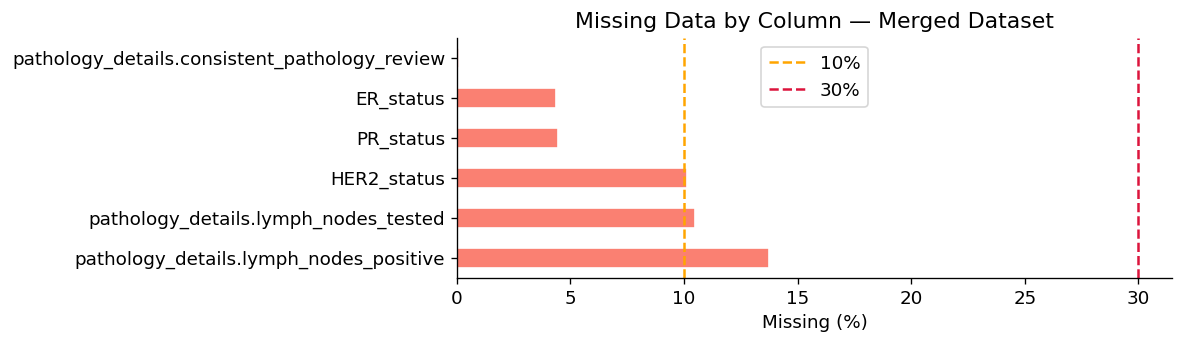

In [25]:
if len(miss_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3, len(miss_nonzero) * 0.4)))
    miss_nonzero.plot(kind='barh', ax=ax, color='salmon', edgecolor='white')
    ax.axvline(10, color='orange',  linestyle='--', lw=1.5, label='10%')
    ax.axvline(30, color='crimson', linestyle='--', lw=1.5, label='30%')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Data by Column — Merged Dataset')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'missing_values_merged.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print('No missing values — nothing to plot.')


## 11. Treatment & Outcome Distributions

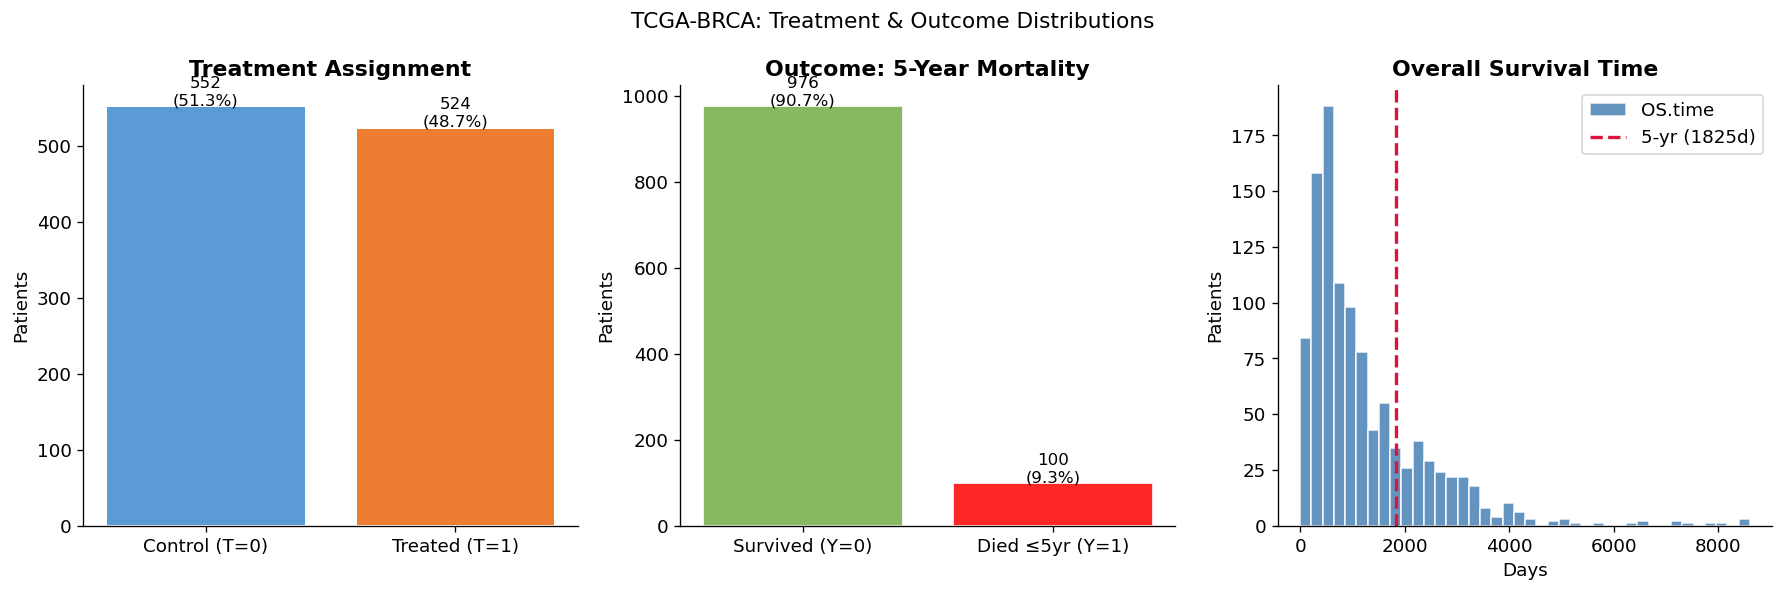


Cross-tabulation T × Y (counts):
Y_died_5yr    0    1   All
T                         
0           491   61   552
1           485   39   524
All         976  100  1076

Row-normalised (%):
Y_died_5yr       0       1
T                         
0          88.9000 11.1000
1          92.6000  7.4000


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# T distribution
counts_t = merged['T'].value_counts().sort_index()
bars = axes[0].bar(['Control (T=0)', 'Treated (T=1)'], counts_t.values,
                   color=['#5B9BD5', '#ED7D31'], edgecolor='white', lw=1.2)
axes[0].set_title('Treatment Assignment', fontweight='bold')
axes[0].set_ylabel('Patients')
for bar, val in zip(bars, counts_t.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val}\n({val/len(merged)*100:.1f}%)', ha='center', fontsize=10)

# Y distribution
counts_y = merged['Y_died_5yr'].value_counts().sort_index()
bars = axes[1].bar(['Survived (Y=0)', 'Died ≤5yr (Y=1)'], counts_y.values,
                   color=['#70AD47', '#FF0000'], edgecolor='white', lw=1.2, alpha=0.85)
axes[1].set_title('Outcome: 5-Year Mortality', fontweight='bold')
axes[1].set_ylabel('Patients')
for bar, val in zip(bars, counts_y.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val}\n({val/len(merged)*100:.1f}%)', ha='center', fontsize=10)

# OS.time histogram
merged[OS_TIME_COL].dropna().plot(kind='hist', bins=40, ax=axes[2],
                                  color='steelblue', edgecolor='white', alpha=0.85)
axes[2].axvline(SURVIVAL_THRESHOLD_DAYS, color='crimson', linestyle='--',
                lw=2, label=f'5-yr ({SURVIVAL_THRESHOLD_DAYS}d)')
axes[2].set_title('Overall Survival Time', fontweight='bold')
axes[2].set_xlabel('Days')
axes[2].set_ylabel('Patients')
axes[2].legend()

plt.suptitle('TCGA-BRCA: Treatment & Outcome Distributions', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'treatment_outcome_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

# Cross-tabulation T x Y
ct = pd.crosstab(merged['T'], merged['Y_died_5yr'],
                 rownames=['T'], colnames=['Y_died_5yr'], margins=True)
print('\nCross-tabulation T × Y (counts):')
print(ct.to_string())
ct_pct = pd.crosstab(merged['T'], merged['Y_died_5yr'],
                     rownames=['T'], colnames=['Y_died_5yr'],
                     normalize='index').mul(100).round(1)
print('\nRow-normalised (%):')
print(ct_pct.to_string())


## 12. Feature Role Assignment (X, T, Y)

In [29]:
OUTCOME_COLS   = {'OS', 'OS.time', 'Y_died_5yr'}
TREATMENT_COLS = {'T'} | set(c for c in merged.columns if 'treatment_or_therapy' in c.lower())
META_COLS      = {'patient_id', 'row_index'}
EXCLUDE        = OUTCOME_COLS | TREATMENT_COLS | META_COLS

covariate_cols = [c for c in merged.columns if c not in EXCLUDE]

print('=== Feature Role Assignment ===')
print(f'  Covariates X        : {len(covariate_cols)}')
print(f'  Treatment T cols    : {sorted(TREATMENT_COLS & set(merged.columns))}')
print(f'  Outcome Y cols      : {sorted(OUTCOME_COLS & set(merged.columns))}')
print(f'  PRIMARY TREATMENT   : T')
print(f'  PRIMARY OUTCOME     : Y_died_5yr')
print(f'\nCovariate column profile:')
for c in covariate_cols:
    print(f'  {c:<65} dtype={str(merged[c].dtype):<10} '
          f'nuniq={merged[c].nunique():<5} miss={merged[c].isnull().sum()}')


=== Feature Role Assignment ===
  Covariates X        : 24
  Treatment T cols    : ["CLIN_treatment_or_therapy.treatments.diagnoses_['not reported', 'not reported']", "CLIN_treatment_or_therapy.treatments.diagnoses_['yes', 'yes']", 'T']
  Outcome Y cols      : ['OS', 'OS.time', 'Y_died_5yr']
  PRIMARY TREATMENT   : T
  PRIMARY OUTCOME     : Y_died_5yr

Covariate column profile:
  CLIN_ajcc_pathologic_stage.diagnoses_Stage IV                     dtype=int64      nuniq=2     miss=0
  CLIN_ajcc_pathologic_m.diagnoses_M1                               dtype=int64      nuniq=2     miss=0
  CLIN_ajcc_pathologic_n.diagnoses_N1b                              dtype=int64      nuniq=2     miss=0
  CLIN_ajcc_staging_system_edition.diagnoses_5th                    dtype=int64      nuniq=2     miss=0
  CLIN_ajcc_staging_system_edition.diagnoses_6th                    dtype=int64      nuniq=2     miss=0
  CLIN_age_at_index.demographic                                     dtype=float64    nuniq=65    mi

## 13. Categorical Encoding

In [31]:
df = merged.copy()

STAGE_MAP = {
    'stage i': 1, 'stage ia': 1, 'stage ib': 1,
    'stage ii': 2, 'stage iia': 2, 'stage iib': 2,
    'stage iii': 3, 'stage iiia': 3, 'stage iiib': 3, 'stage iiic': 3,
    'stage iv': 4, 'i': 1, 'ii': 2, 'iii': 3, 'iv': 4
}

ONEHOT_MAX = 10
binary_encoded   = []
onehot_encoded   = []
stage_encoded    = []
dropped_highcard = []

object_cov = [c for c in covariate_cols if df[c].dtype == object]
print(f'Object-type covariates: {len(object_cov)}')

for col in object_cov:
    n_unique = df[col].nunique(dropna=True)
    if n_unique == 0:
        df.drop(columns=[col], inplace=True)
        dropped_highcard.append(col)
    elif 'stage' in col.lower():
        df[col] = df[col].astype(str).str.lower().str.strip().map(STAGE_MAP)
        stage_encoded.append(col)
    elif n_unique <= 2:
        df[col] = (df[col].astype(str).str.lower()
                   .isin(['yes', '1', 'positive', 'true'])).astype(int)
        binary_encoded.append(col)
    elif n_unique <= ONEHOT_MAX:
        onehot_encoded.append(col)
    else:
        df.drop(columns=[col], inplace=True)
        dropped_highcard.append(col)

if onehot_encoded:
    df = pd.get_dummies(df, columns=onehot_encoded, drop_first=True, dtype=int)

covariate_cols = [c for c in df.columns if c not in EXCLUDE and c not in META_COLS]

print(f'Binary encoded     : {len(binary_encoded)}  → {binary_encoded}')
print(f'Stage encoded      : {len(stage_encoded)}  → {stage_encoded}')
print(f'One-hot encoded    : {len(onehot_encoded)}  → {onehot_encoded}')
print(f'Dropped (high-card): {len(dropped_highcard)}')
print(f'Shape after encoding: {df.shape}')


Object-type covariates: 1
Binary encoded     : 1  → ['pathology_details.consistent_pathology_review']
Stage encoded      : 0  → []
One-hot encoded    : 0  → []
Dropped (high-card): 0
Shape after encoding: (1076, 32)


## 14. Missing Value Imputation (MICE + Median)

In [33]:
num_cov = [c for c in covariate_cols
           if pd.api.types.is_numeric_dtype(df[c]) and c in df.columns]

miss_frac = df[num_cov].isnull().mean()
mice_cols   = miss_frac[miss_frac.between(0.001, 0.30)].index.tolist()
median_cols = miss_frac[miss_frac > 0.30].index.tolist()

print(f'No missing         : {(miss_frac == 0).sum()} cols')
print(f'MICE (<30% miss)   : {len(mice_cols)} cols → {mice_cols}')
print(f'Median (≥30% miss) : {len(median_cols)} cols → {median_cols}')

for col in median_cols:
    df[col + '_was_missing'] = df[col].isnull().astype(int)
    df[col].fillna(df[col].median(), inplace=True)

if mice_cols:
    mice = IterativeImputer(max_iter=10, random_state=42, sample_posterior=False)
    df[mice_cols] = mice.fit_transform(df[mice_cols])
    print('MICE imputation complete.')

print(f'\nRemaining missing in numeric covariates: {df[num_cov].isnull().sum().sum()}')


No missing         : 19 cols
MICE (<30% miss)   : 5 cols → ['pathology_details.lymph_nodes_positive', 'pathology_details.lymph_nodes_tested', 'ER_status', 'HER2_status', 'PR_status']
Median (≥30% miss) : 0 cols → []
MICE imputation complete.

Remaining missing in numeric covariates: 0


## 15. Outlier Capping (Winsorisation 1st–99th percentile)

In [35]:
continuous_cov = [c for c in num_cov if df[c].nunique() > 10]

cap_report = []
for col in continuous_cov:
    q01, q99 = df[col].quantile(0.01), df[col].quantile(0.99)
    n_capped = int(((df[col] < q01) | (df[col] > q99)).sum())
    df[col] = df[col].clip(lower=q01, upper=q99)
    cap_report.append({'column': col, 'n_capped': n_capped,
                       'q01': round(q01, 4), 'q99': round(q99, 4)})

cap_df = pd.DataFrame(cap_report)
capped = cap_df[cap_df['n_capped'] > 0]
print(f'Columns with capped values: {len(capped)} / {len(continuous_cov)}')
if len(capped):
    print(capped.to_string(index=False))
else:
    print('No outliers capped.')


Columns with capped values: 8 / 11
                                column  n_capped     q01     q99
         CLIN_age_at_index.demographic        20 30.0000 87.0000
                            PROT_4EBP1        22 -0.8663  1.5994
                           PROT_ZAP-70        22 -1.1536  2.1299
                       METH_cg00101629        22 -2.7670  3.2407
                 RNA_ENSG00000264589.4        11 -1.7741  1.8766
                       METH_cg19851563        22 -3.5448  4.2401
pathology_details.lymph_nodes_positive        20  0.0000 24.2500
  pathology_details.lymph_nodes_tested        15  1.0000 36.2500


## 16. Standardisation

In [37]:
covariate_cols_final = [
    c for c in df.columns
    if c not in EXCLUDE and c not in META_COLS
    and pd.api.types.is_numeric_dtype(df[c])
]

continuous_to_scale = [c for c in covariate_cols_final if df[c].nunique() > 10]

scaler = StandardScaler()
df_scaled = df.copy()
if continuous_to_scale:
    df_scaled[continuous_to_scale] = scaler.fit_transform(df[continuous_to_scale])
    print(f'Standardised {len(continuous_to_scale)} continuous covariates.')
else:
    print('No continuous covariates to standardise.')

# Integrity checks
assert df_scaled['T'].isin([0, 1]).all(), 'ERROR: T column corrupted by scaling!'
assert df_scaled['Y_died_5yr'].isin([0, 1]).all(), 'ERROR: Y column corrupted!'
print(f'T integrity check: OK  (T=1: {df_scaled["T"].sum()}, T=0: {(df_scaled["T"]==0).sum()})')
print(f'Y integrity check: OK  (Y=1: {df_scaled["Y_died_5yr"].sum()}, Y=0: {(df_scaled["Y_died_5yr"]==0).sum()})')
print(f'\nFinal scaled dataset: {df_scaled.shape}')
print(f'Covariate columns (X): {len(covariate_cols_final)}')


Standardised 11 continuous covariates.
T integrity check: OK  (T=1: 524, T=0: 552)
Y integrity check: OK  (Y=1: 100, Y=0: 976)

Final scaled dataset: (1076, 32)
Covariate columns (X): 24


## 17. Propensity Score & Common Support Check

Standardised Mean Difference (SMD) — pre-weighting:
  Mean SMD : 0.1166
  Max SMD  : 0.3621
Covariates with SMD > 0.1 (potential confounders):
pathology_details.lymph_nodes_positive                                    0.3621
CLIN_age_at_index.demographic                                             0.3077
pathology_details.lymph_nodes_tested                                      0.2923
CLIN_ajcc_staging_system_edition.diagnoses_5th                            0.2484
PROT_ZAP-70                                                               0.1967
CLIN_tissue_or_organ_of_origin.diagnoses_Breast, NOS                      0.1919
METH_cg19851563                                                           0.1395
METH_cg00101629                                                           0.1193
CLIN_tissue_or_organ_of_origin.diagnoses_Lower-inner quadrant of breast   0.1044
CLIN_ajcc_staging_system_edition.diagnoses_6th                            0.1034


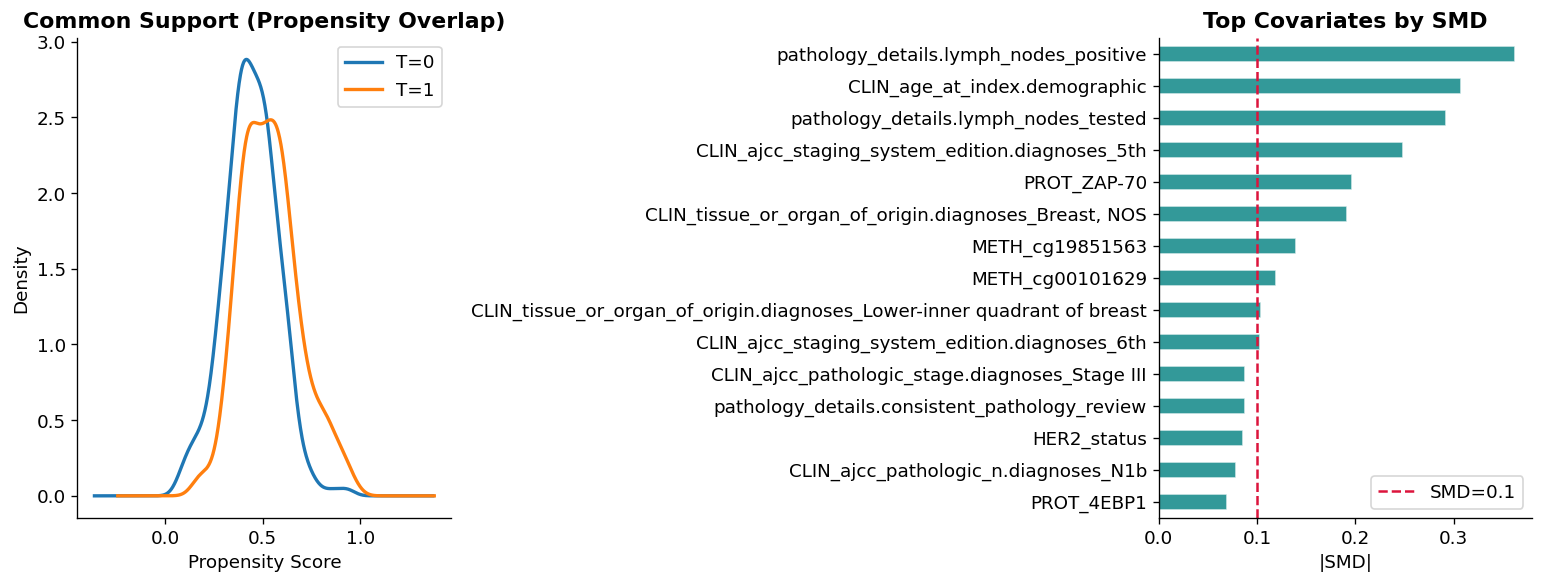

Propensity range: [0.071, 0.974]


In [39]:
X_num = df_scaled[covariate_cols_final].fillna(0)
T_vec = df_scaled['T'].astype(int)

treated_df = df_scaled[T_vec == 1][covariate_cols_final]
control_df = df_scaled[T_vec == 0][covariate_cols_final]

smd = ((treated_df.mean() - control_df.mean()).abs() /
       (np.sqrt((treated_df.var() + control_df.var()) / 2) + 1e-8))
smd = smd.sort_values(ascending=False)

print('Standardised Mean Difference (SMD) — pre-weighting:')
print(f'  Mean SMD : {smd.mean():.4f}')
print(f'  Max SMD  : {smd.max():.4f}')
print('Covariates with SMD > 0.1 (potential confounders):')
print(smd[smd > 0.1].round(4).to_string() or '  None — good baseline balance')

lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_num, T_vec)
df_scaled['propensity_score'] = lr.predict_proba(X_num)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, grp in df_scaled.groupby('T'):
    grp['propensity_score'].plot(kind='kde', ax=axes[0],
                                 label=f'T={int(label)}', linewidth=2)
axes[0].set_xlabel('Propensity Score')
axes[0].set_title('Common Support (Propensity Overlap)', fontweight='bold')
axes[0].legend()

smd.head(15).sort_values().plot(kind='barh', ax=axes[1],
                                 color='teal', alpha=0.8, edgecolor='white')
axes[1].axvline(0.1, color='crimson', linestyle='--', lw=1.5, label='SMD=0.1')
axes[1].set_xlabel('|SMD|')
axes[1].set_title('Top Covariates by SMD', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'propensity_smd.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Propensity range: [{df_scaled["propensity_score"].min():.3f}, {df_scaled["propensity_score"].max():.3f}]')


## 18. Build ITE-Ready Dataset

In [41]:
X = df_scaled[covariate_cols_final].fillna(0)
T = df_scaled['T'].astype(int)
Y = df_scaled['Y_died_5yr'].astype(int)

print('=== ITE-Ready Dataset ===')
print(f'  Patients     : {X.shape[0]}')
print(f'  Covariates X : {X.shape[1]}')
print(f'  T=1 (treated): {T.sum()} ({T.mean()*100:.1f}%)')
print(f'  Y=1 (event)  : {Y.sum()} ({Y.mean()*100:.1f}%)')
print(f'  NaN in X     : {X.isnull().sum().sum()}')
print(f'  NaN in T     : {T.isnull().sum()}')
print(f'  NaN in Y     : {Y.isnull().sum()}')
print(f'\nX columns:')
for c in X.columns:
    print(f'  {c}')


=== ITE-Ready Dataset ===
  Patients     : 1076
  Covariates X : 24
  T=1 (treated): 524 (48.7%)
  Y=1 (event)  : 100 (9.3%)
  NaN in X     : 0
  NaN in T     : 0
  NaN in Y     : 0

X columns:
  CLIN_ajcc_pathologic_stage.diagnoses_Stage IV
  CLIN_ajcc_pathologic_m.diagnoses_M1
  CLIN_ajcc_pathologic_n.diagnoses_N1b
  CLIN_ajcc_staging_system_edition.diagnoses_5th
  CLIN_ajcc_staging_system_edition.diagnoses_6th
  CLIN_age_at_index.demographic
  CLIN_ajcc_pathologic_n.diagnoses_N0 (i-)
  CLIN_ajcc_pathologic_n.diagnoses_NX
  PROT_4EBP1
  PROT_ZAP-70
  METH_cg00101629
  CLIN_ajcc_pathologic_t.diagnoses_T4b
  RNA_ENSG00000264589.4
  CLIN_tissue_or_organ_of_origin.diagnoses_Lower-inner quadrant of breast
  CLIN_tissue_or_organ_of_origin.diagnoses_Breast, NOS
  METH_cg19851563
  CLIN_ajcc_staging_system_edition.diagnoses_4th
  CLIN_ajcc_pathologic_stage.diagnoses_Stage III
  pathology_details.consistent_pathology_review
  pathology_details.lymph_nodes_positive
  pathology_details.lymph_no

## 19. Save All Outputs

In [43]:
import joblib

df_scaled.to_csv(OUTPUT_DIR / 'merged_preprocessed.csv', index=False)
print(f'Saved: merged_preprocessed.csv       {df_scaled.shape}')

ite_df = pd.concat([
    X.reset_index(drop=True),
    T.rename('T').reset_index(drop=True),
    Y.rename('Y').reset_index(drop=True),
    df_scaled['patient_id'].reset_index(drop=True),
    df_scaled['propensity_score'].reset_index(drop=True),
], axis=1)
ite_df.to_csv(OUTPUT_DIR / 'ite_ready_dataset.csv', index=False)
print(f'Saved: ite_ready_dataset.csv         {ite_df.shape}')

if continuous_to_scale:
    joblib.dump({'scaler': scaler, 'continuous_cols': continuous_to_scale},
                OUTPUT_DIR / 'standard_scaler.pkl')
    print('Saved: standard_scaler.pkl')

meta = {
    'n_patients':            int(X.shape[0]),
    'n_covariates':          int(X.shape[1]),
    'covariate_columns':     X.columns.tolist(),
    'primary_treatment_col': 'T',
    'primary_outcome_col':   'Y_died_5yr',
    'treatment_prevalence':  float(T.mean()),
    'outcome_prevalence':    float(Y.mean()),
    'outcome_horizon_days':  SURVIVAL_THRESHOLD_DAYS,
    'smd_mean':              float(smd.mean()),
    'smd_max':               float(smd.max()),
    'mice_imputed_cols':     mice_cols,
    'median_imputed_cols':   median_cols,
    'continuous_scaled_cols': continuous_to_scale,
}
with open(OUTPUT_DIR / 'preprocessing_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('Saved: preprocessing_metadata.json')
print('\n=== All outputs saved ===')


Saved: merged_preprocessed.csv       (1076, 33)
Saved: ite_ready_dataset.csv         (1076, 28)
Saved: standard_scaler.pkl
Saved: preprocessing_metadata.json

=== All outputs saved ===


## 20. Summary

In [45]:
print('=' * 62)
print('  PREPROCESSING COMPLETE')
print('=' * 62)
print(f'  Patients in ITE dataset      : {X.shape[0]}')
print(f'  Covariates (X)               : {X.shape[1]}')
print(f'  Treatment T=1 / T=0          : {T.sum()} / {(T==0).sum()}')
print(f'  Outcome Y=1 / Y=0            : {Y.sum()} / {(Y==0).sum()}')
print(f'  Propensity range             : [{df_scaled["propensity_score"].min():.3f}, '
      f'{df_scaled["propensity_score"].max():.3f}]')
print(f'  Pre-treatment SMD mean/max   : {smd.mean():.3f} / {smd.max():.3f}')
print()
print('  OUTPUT FILES:')
print('    ite_ready_dataset.csv       → X, T, Y, propensity per patient')
print('    merged_preprocessed.csv     → full feature matrix')
print('    standard_scaler.pkl         → scaler for inverse transform')
print('    preprocessing_metadata.json → column lists, statistics')
print()
print('  NEXT: 03_ite_estimation.ipynb')
print('    Models  : S-Learner → T-Learner → X-Learner')
print('    Metrics : ATE, ATT, PEHE, uplift curve, AUPRC')
print('=' * 62)


  PREPROCESSING COMPLETE
  Patients in ITE dataset      : 1076
  Covariates (X)               : 24
  Treatment T=1 / T=0          : 524 / 552
  Outcome Y=1 / Y=0            : 100 / 976
  Propensity range             : [0.071, 0.974]
  Pre-treatment SMD mean/max   : 0.117 / 0.362

  OUTPUT FILES:
    ite_ready_dataset.csv       → X, T, Y, propensity per patient
    merged_preprocessed.csv     → full feature matrix
    standard_scaler.pkl         → scaler for inverse transform
    preprocessing_metadata.json → column lists, statistics

  NEXT: 03_ite_estimation.ipynb
    Models  : S-Learner → T-Learner → X-Learner
    Metrics : ATE, ATT, PEHE, uplift curve, AUPRC
